# Homework Assignment 2: Regression and Classification Error Analysis

## Objective

This notebook investigates regression and classification models through systematic error analysis.

The regression task predicts the total number of goals in a football match.

The classification task predicts whether the home team wins.

All analyses are conducted using k-fold cross-validation. The goal is not only to compare model performance, but also to understand where and why the models fail.

In [17]:
import os
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from IPython.display import display, Markdown

from sklearn.model_selection import KFold, cross_val_predict
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer

from sklearn.dummy import DummyRegressor, DummyClassifier
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.tree import DecisionTreeRegressor, DecisionTreeClassifier
from sklearn.ensemble import (
    RandomForestRegressor,
    RandomForestClassifier,
    GradientBoostingRegressor,
    GradientBoostingClassifier,
)

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    fbeta_score,
    matthews_corrcoef,
    confusion_matrix,
    roc_auc_score,
    roc_curve,
    brier_score_loss,
)

from sklearn.calibration import calibration_curve

RANDOM_STATE = 42
sns.set_theme(style="whitegrid")


def md(text):
    display(Markdown(text))


def find_file(possible_names):
    for name in possible_names:
        if os.path.exists(name):
            return name
    return None

## 1. Data Loading

The dataset is loaded from `ginf.csv`. The file contains match-level football data, including country, league, season, teams, betting odds, and final score.

The modeling unit is one football match.

In [24]:
md("## 1. Data Loading and Feature Engineering")

matches = pd.read_csv(ginf_path)
matches.columns = matches.columns.str.strip().str.lower()

matches["date"] = pd.to_datetime(matches["date"], errors="coerce")
matches["year"] = matches["date"].dt.year
matches["month"] = matches["date"].dt.month
matches["dayofweek"] = matches["date"].dt.dayofweek

matches["total_goals"] = matches["fthg"] + matches["ftag"]
matches["home_win"] = (matches["fthg"] > matches["ftag"]).astype(int)

md(f"Loaded match-level data with **{matches.shape[0]:,} rows** and **{matches.shape[1]:,} columns**.")

md("""
This analysis uses only the match-level file `ginf.csv`.

The event-level file is not used in this notebook. This keeps the modeling task cleaner and avoids using in-match event information to predict final match outcomes.
""")

matches = matches.dropna(subset=["total_goals", "home_win"])

exclude_cols = {
    "id_odsp", "link_odsp", "date",
    "fthg", "ftag",
    "total_goals", "home_win"
}

feature_cols = [c for c in matches.columns if c not in exclude_cols]

X = matches[feature_cols].copy()
y_reg = matches["total_goals"].copy()
y_clf = matches["home_win"].copy()

numeric_features = X.select_dtypes(include=[np.number, "bool"]).columns.tolist()
categorical_features = [c for c in X.columns if c not in numeric_features]

md(f"""
**Final modeling dataset**

- Observations: **{X.shape[0]:,}**
- Features before preprocessing: **{X.shape[1]:,}**
- Numeric features: **{len(numeric_features):,}**
- Categorical features: **{len(categorical_features):,}**
- Regression target: `total_goals`
- Classification target: `home_win`
""")

display(
    matches[
        ["date", "country", "league", "ht", "at", "fthg", "ftag", "total_goals", "home_win"]
    ].head()
)

## 1. Data Loading and Feature Engineering

Loaded match-level data with **10,112 rows** and **23 columns**.


This analysis uses only the match-level file `ginf.csv`.

The event-level file is not used in this notebook. This keeps the modeling task cleaner and avoids using in-match event information to predict final match outcomes.



**Final modeling dataset**

- Observations: **10,112**
- Features before preprocessing: **16**
- Numeric features: **12**
- Categorical features: **4**
- Regression target: `total_goals`
- Classification target: `home_win`


,date,country,league,ht,at,fthg,ftag,total_goals,home_win
0,2011-08-05,germany,D1,Borussia Dortmund,Hamburg SV,3,1,4,1
1,2011-08-06,germany,D1,FC Augsburg,SC Freiburg,2,2,4,0
2,2011-08-06,germany,D1,Werder Bremen,Kaiserslautern,2,0,2,1
3,2011-08-06,france,F1,Paris Saint-Germain,Lorient,0,1,1,0
4,2011-08-06,france,F1,Caen,Valenciennes,1,0,1,1


### Explanation

The match-level file is loaded first. The date column is converted into numerical time-related features: year, month, and day of week.

Two target variables are created. For regression, the target variable is `total_goals`, defined as the sum of home-team goals and away-team goals. For classification, the target variable is `home_win`, which equals 1 when the home team scores more goals than the away team and 0 otherwise.

The feature set excludes identifiers, direct score variables, and the target variables. In particular, `fthg` and `ftag` are not used as predictors because they directly determine the targets. This prevents direct target leakage.

The current analysis uses only the match-level file `ginf.csv`. This is a safer modeling choice because it avoids using in-match event information to predict final match outcomes.

In [25]:
# 2. Preprocessing and cross-validation design

md("## 2. Cross-Validation Design")

md("""
**Choice of k.**

I use **5-fold cross-validation** with shuffling and a fixed random seed.

This is appropriate because the dataset has a large number of match-level observations. Each fold is large enough to produce stable estimates, while the computational cost remains reasonable.

A larger value such as k = 10 could reduce bias slightly, but it would increase computation time, especially for ensemble models. A smaller value such as k = 3 would be faster, but the performance estimates would be more variable.

Therefore, k = 5 is a balanced choice in terms of dataset size, computational complexity, and the bias-variance trade-off.
""")

kf = KFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)


def make_ohe():
    """
    Create OneHotEncoder in a way that works across different sklearn versions.
    """
    try:
        return OneHotEncoder(handle_unknown="ignore", sparse_output=False)
    except TypeError:
        return OneHotEncoder(handle_unknown="ignore", sparse=False)


numeric_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
    ]
)

categorical_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("onehot", make_ohe()),
    ]
)

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features),
    ],
    remainder="drop",
)

## 2. Cross-Validation Design


**Choice of k.**

I use **5-fold cross-validation** with shuffling and a fixed random seed.

This is appropriate because the dataset has a large number of match-level observations. Each fold is large enough to produce stable estimates, while the computational cost remains reasonable.

A larger value such as k = 10 could reduce bias slightly, but it would increase computation time, especially for ensemble models. A smaller value such as k = 3 would be faster, but the performance estimates would be more variable.

Therefore, k = 5 is a balanced choice in terms of dataset size, computational complexity, and the bias-variance trade-off.


Explanation

The analysis uses 5-fold cross-validation. This means that the dataset is divided into five parts. In each iteration, four parts are used for training and one part is used for validation. This process is repeated five times so that every observation receives an out-of-fold prediction.

This approach is stronger than a single train-test split because it uses the entire dataset for validation across folds and provides more stable estimates of model behavior.

The preprocessing pipeline handles numerical and categorical features separately. Numerical features are imputed using the median and then standardized. Categorical features are imputed using the most frequent value and then converted into dummy variables using one-hot encoding.

Using a preprocessing pipeline is important because it prevents data leakage. Imputation, scaling, and encoding are learned only from the training folds and then applied to the validation fold.

In [26]:
# 3. Regression models and performance comparison

md("## 3. Regression Models")

regression_models = {
    "Dummy Mean Regressor": DummyRegressor(strategy="mean"),

    "Linear Regression": LinearRegression(),

    "Decision Tree Regressor": DecisionTreeRegressor(
        max_depth=6,
        min_samples_leaf=20,
        random_state=RANDOM_STATE,
    ),

    "Random Forest Regressor": RandomForestRegressor(
        n_estimators=200,
        max_depth=12,
        min_samples_leaf=5,
        random_state=RANDOM_STATE,
        n_jobs=-1,
    ),

    "Gradient Boosting Regressor": GradientBoostingRegressor(
        random_state=RANDOM_STATE,
    ),
}

regression_results = []
regression_predictions = {}

for name, model in regression_models.items():
    pipe = Pipeline(
        steps=[
            ("preprocess", preprocessor),
            ("model", model),
        ]
    )

    y_pred = cross_val_predict(pipe, X, y_reg, cv=kf, n_jobs=None)
    residuals = y_reg - y_pred

    mae = mean_absolute_error(y_reg, y_pred)
    mse = mean_squared_error(y_reg, y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_reg, y_pred)

    resid_std = residuals.std()
    resid_skew = pd.Series(residuals).skew()
    resid_kurt = pd.Series(residuals).kurtosis()

    regression_predictions[name] = y_pred

    regression_results.append(
        {
            "Model": name,
            "MAE": mae,
            "MSE": mse,
            "RMSE": rmse,
            "R2": r2,
            "Residual_STD": resid_std,
            "Residual_Skewness": resid_skew,
            "Residual_Kurtosis": resid_kurt,
        }
    )

reg_results_df = pd.DataFrame(regression_results).sort_values("RMSE")

display(
    reg_results_df.style.format(
        {
            "MAE": "{:.4f}",
            "MSE": "{:.4f}",
            "RMSE": "{:.4f}",
            "R2": "{:.4f}",
            "Residual_STD": "{:.4f}",
            "Residual_Skewness": "{:.4f}",
            "Residual_Kurtosis": "{:.4f}",
        }
    )
)

best_reg_model_name = reg_results_df.iloc[0]["Model"]
best_reg_pred = regression_predictions[best_reg_model_name]

reg_residuals = y_reg - best_reg_pred
reg_abs_errors = np.abs(reg_residuals)

md(f"**Preferred regression model for error analysis:** `{best_reg_model_name}`, selected by the lowest RMSE.")

## 3. Regression Models

,Model,MAE,MSE,RMSE,R2,Residual_STD,Residual_Skewness,Residual_Kurtosis
3,Random Forest Regressor,1.3181,2.7218,1.6498,0.0421,1.6499,0.5457,0.3364
4,Gradient Boosting Regressor,1.3204,2.7269,1.6513,0.0403,1.6514,0.5507,0.3183
2,Decision Tree Regressor,1.3296,2.7743,1.6656,0.0236,1.6657,0.5439,0.3190
1,Linear Regression,1.3295,2.7776,1.6666,0.0224,1.6667,0.5219,0.3136
0,Dummy Mean Regressor,1.3553,2.8430,1.6861,-0.0006,1.6862,0.6105,0.4497


**Preferred regression model for error analysis:** `Random Forest Regressor`, selected by the lowest RMSE.

### Explanation

Five regression models are evaluated: Dummy Mean Regressor, Linear Regression, Decision Tree Regressor, Random Forest Regressor, and Gradient Boosting Regressor.

The Dummy Mean Regressor is used as a simple baseline. It always predicts the average number of goals. This helps check whether the other models actually learn useful patterns from the data.

All models are trained and evaluated using the same feature set and the same 5-fold cross-validation design. This ensures a fair comparison.

The evaluation includes MAE, MSE, RMSE, and R². MAE measures the average absolute prediction error. MSE and RMSE penalize large errors more strongly. R² measures how much variation in the target is explained by the model.

The table also reports statistical properties of the residuals: standard deviation, skewness, and kurtosis. These values help understand whether the model errors are stable, biased, or heavy-tailed.

The model with the lowest RMSE is selected for detailed regression error analysis. In this run, the Random Forest Regressor is selected.

Although the Random Forest Regressor performs best, the R² value is still low. This means that total goals are difficult to predict from the available match-level variables. This is reasonable because football goals are affected by missing contextual factors such as injuries, lineups, red cards, tactical decisions, and random match events.

## 4. Regression Error Analysis

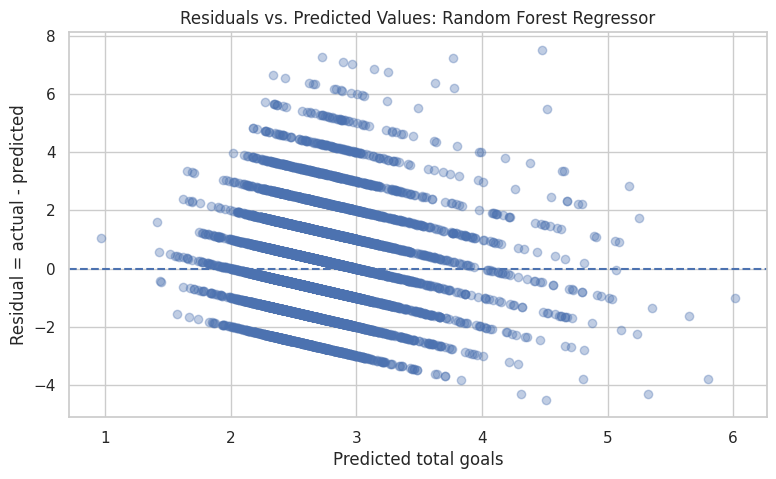

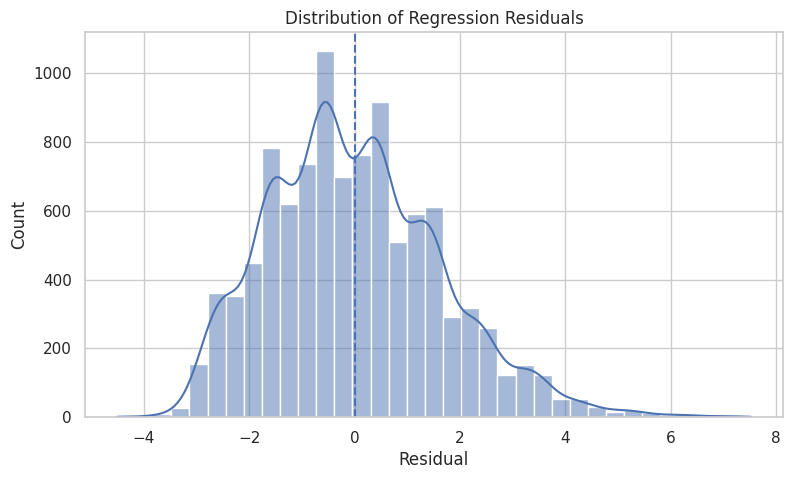

,prediction_bin,mean_predicted,mean_residual,residual_std,mean_absolute_error,n
0,"(0.965, 2.391]",2.244728,0.078060,1.524653,1.213761,2023
1,"(2.391, 2.573]",2.482268,0.009324,1.571369,1.280935,2022
2,"(2.573, 2.739]",2.654911,-0.010994,1.643930,1.333420,2022
3,"(2.739, 2.95]",2.840513,-0.033886,1.717162,1.353275,2022
4,"(2.95, 6.014]",3.275847,-0.025723,1.778341,1.408991,2023



### 4.1 Residual Interpretation

- The mean residual is **0.0034**. If this value is close to zero, the residuals are approximately centered around zero.
- The residual standard deviation is **1.6498**.
- The residual skewness is **0.5457**. A positive value means the model sometimes underestimates high-scoring matches. A negative value means it sometimes overestimates.
- The residual kurtosis is **0.3364**. High kurtosis indicates heavy tails and instability in rare matches.
- The Spearman correlation between predicted values and absolute errors is **0.0582**. A high positive value would indicate heteroscedasticity, meaning that errors increase as predicted goals increase.


In [27]:
# 4. Regression residual analysis

md("## 4. Regression Error Analysis")

# Residuals vs predicted values.
plt.figure(figsize=(9, 5))
plt.scatter(best_reg_pred, reg_residuals, alpha=0.35)
plt.axhline(0, linestyle="--")
plt.xlabel("Predicted total goals")
plt.ylabel("Residual = actual - predicted")
plt.title(f"Residuals vs. Predicted Values: {best_reg_model_name}")
plt.show()

# Residual distribution.
plt.figure(figsize=(9, 5))
sns.histplot(reg_residuals, bins=35, kde=True)
plt.axvline(0, linestyle="--")
plt.xlabel("Residual")
plt.title("Distribution of Regression Residuals")
plt.show()

# Residual bin analysis for heteroscedasticity.
resid_df = pd.DataFrame(
    {
        "actual": y_reg,
        "predicted": best_reg_pred,
        "residual": reg_residuals,
        "absolute_error": reg_abs_errors,
    }
)

resid_df["prediction_bin"] = pd.qcut(
    resid_df["predicted"],
    q=5,
    duplicates="drop",
)

resid_bin_summary = (
    resid_df.groupby("prediction_bin")
    .agg(
        mean_predicted=("predicted", "mean"),
        mean_residual=("residual", "mean"),
        residual_std=("residual", "std"),
        mean_absolute_error=("absolute_error", "mean"),
        n=("residual", "size"),
    )
    .reset_index()
)

display(resid_bin_summary)

corr_abs_error_pred = pd.Series(reg_abs_errors).corr(
    pd.Series(best_reg_pred),
    method="spearman",
)

mean_resid = np.mean(reg_residuals)
std_resid = np.std(reg_residuals)
skew_resid = pd.Series(reg_residuals).skew()
kurt_resid = pd.Series(reg_residuals).kurtosis()

md(f"""
### 4.1 Residual Interpretation

- The mean residual is **{mean_resid:.4f}**. If this value is close to zero, the residuals are approximately centered around zero.
- The residual standard deviation is **{std_resid:.4f}**.
- The residual skewness is **{skew_resid:.4f}**. A positive value means the model sometimes underestimates high-scoring matches. A negative value means it sometimes overestimates.
- The residual kurtosis is **{kurt_resid:.4f}**. High kurtosis indicates heavy tails and instability in rare matches.
- The Spearman correlation between predicted values and absolute errors is **{corr_abs_error_pred:.4f}**. A high positive value would indicate heteroscedasticity, meaning that errors increase as predicted goals increase.
""")

### Explanation

The residual is defined as the actual value minus the predicted value.

The residuals are approximately centered around zero because the mean residual is close to zero. This suggests that the model does not have a strong overall tendency to overpredict or underpredict total goals.

The residual plot shows a clear banded structure. This happens because the actual number of goals is a discrete integer variable, while the model predictions are continuous.

The residual distribution has a positive tail, which means that the model sometimes underestimates high-scoring matches. This is reasonable because high-scoring football matches are relatively rare and difficult to predict.

The residual bin summary is used to check whether the error variance changes across predicted values. Since the residual standard deviation is not exactly constant across bins, there is some evidence of non-constant error variance.

Overall, the residual analysis shows that the model is reasonably centered but struggles with rare high-scoring matches and extreme outcomes.

### 4.2 Error as a Function of Features

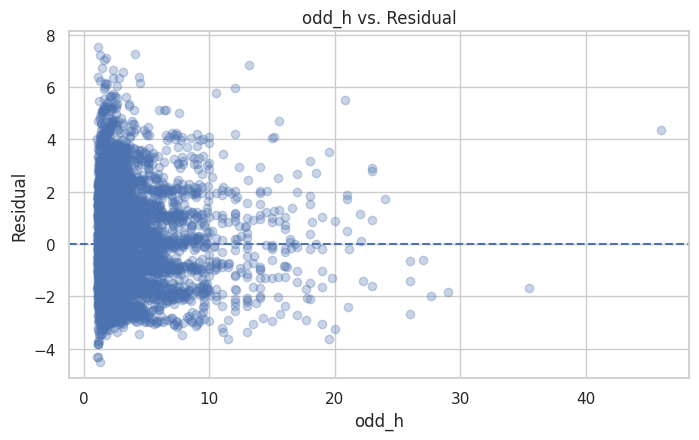

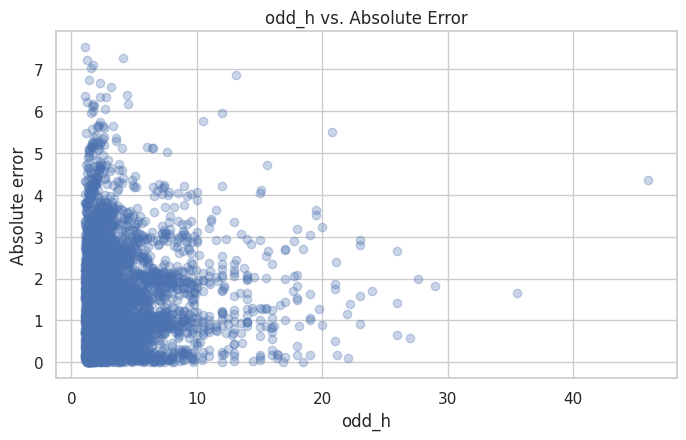

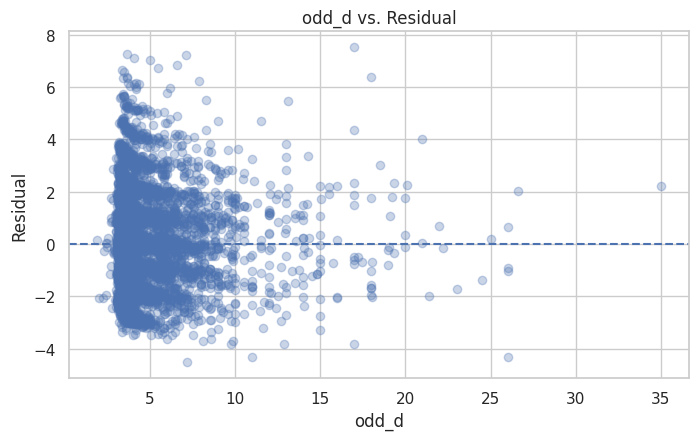

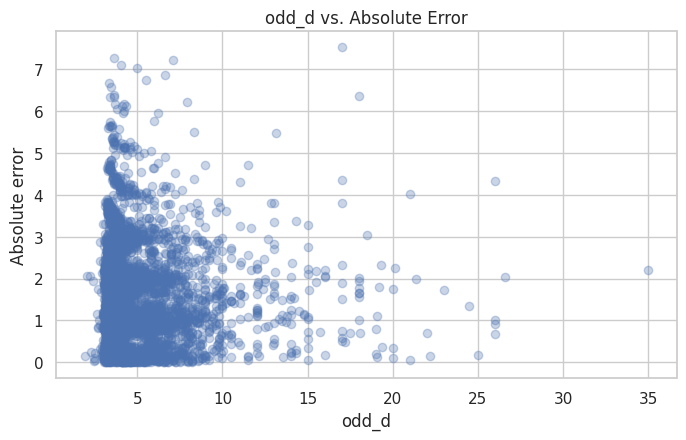

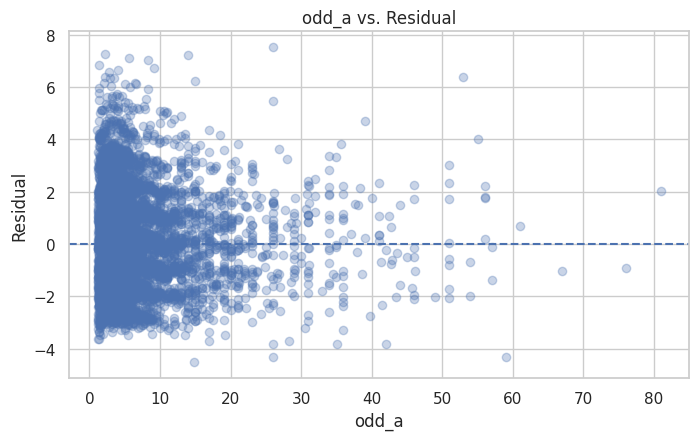

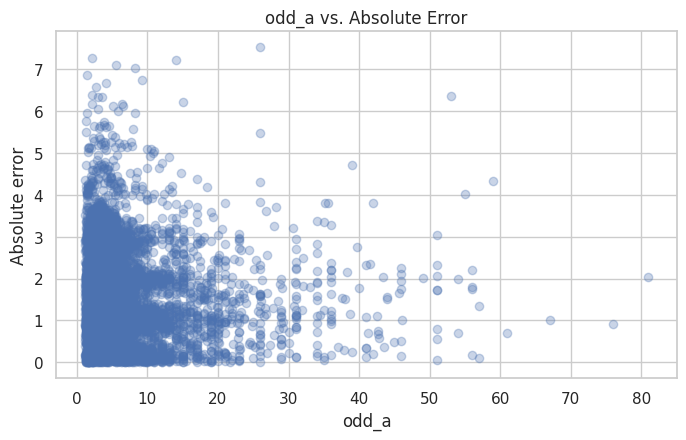

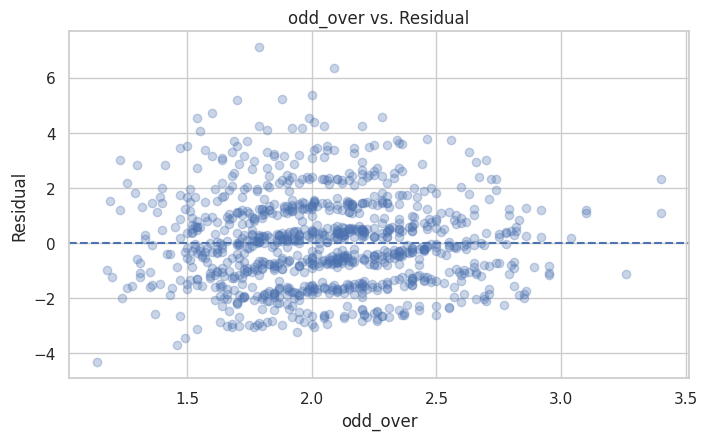

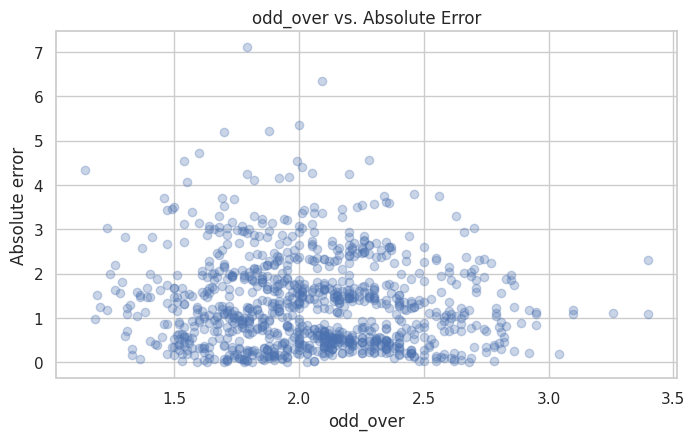

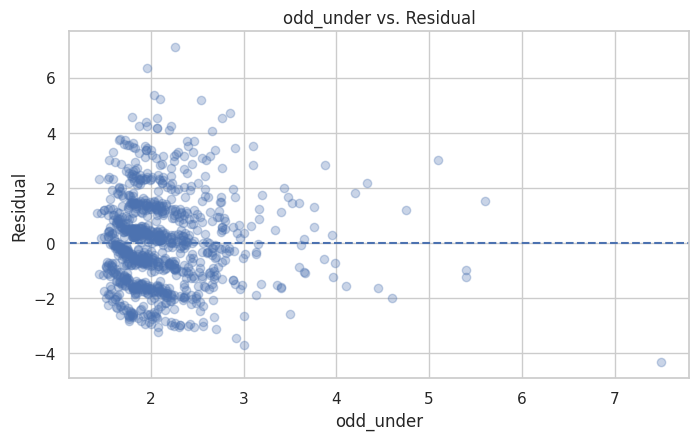

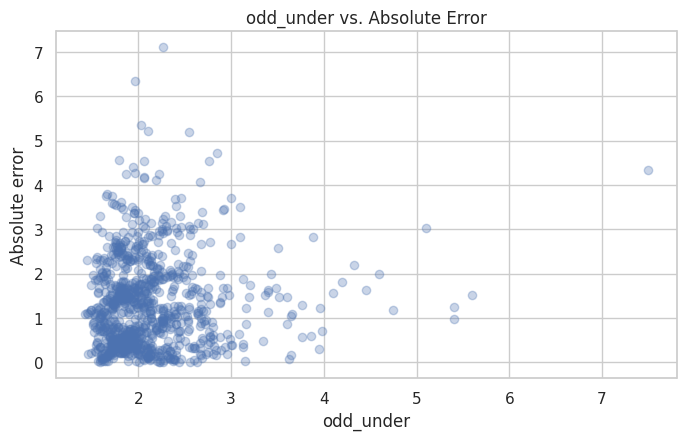

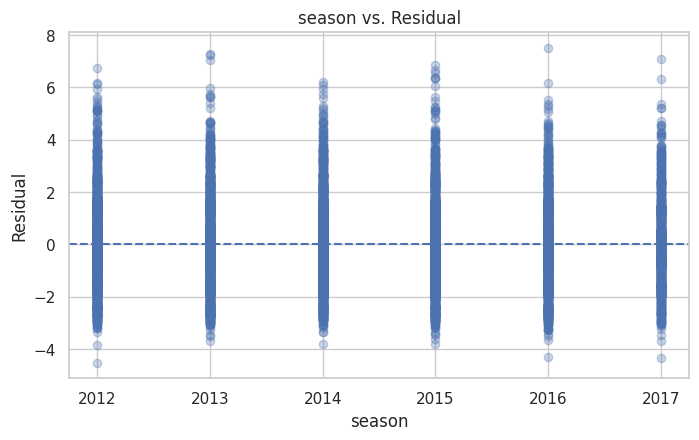

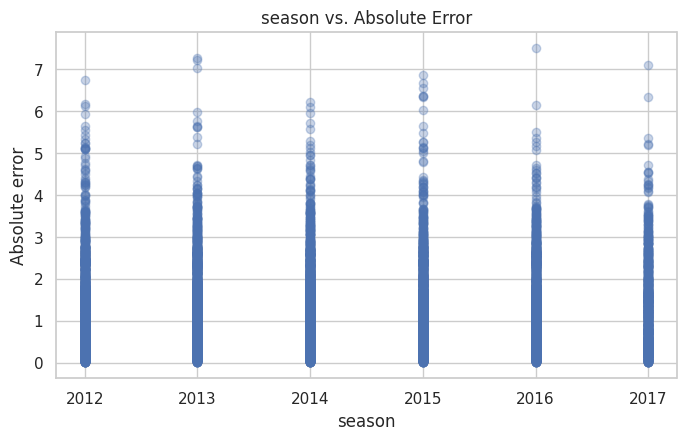

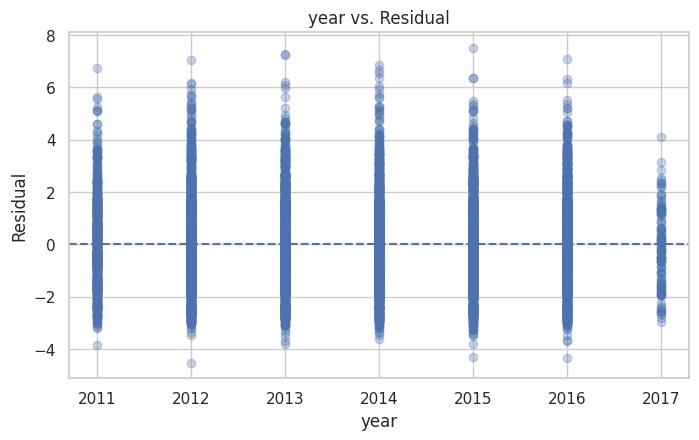

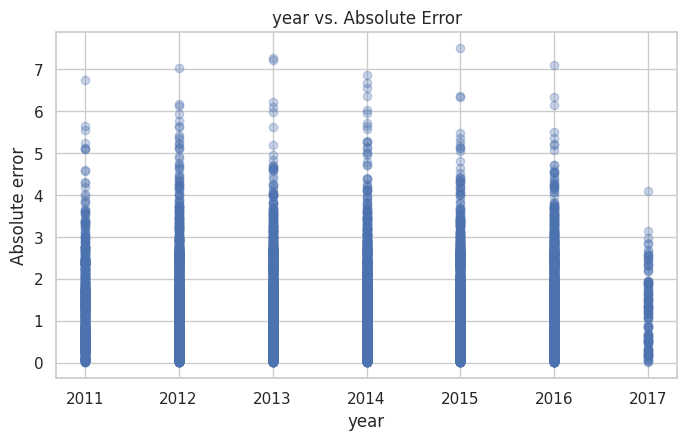

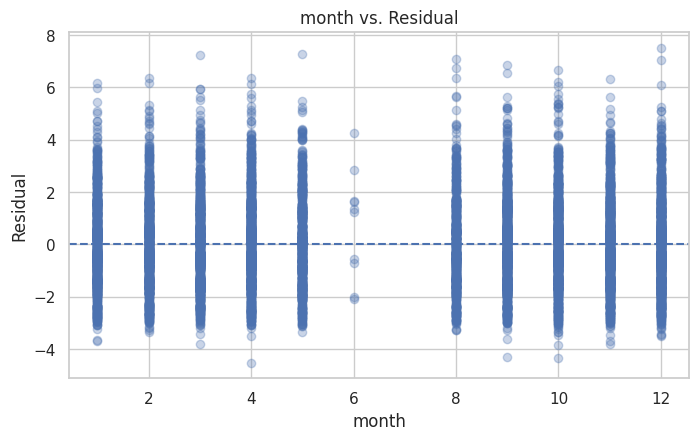

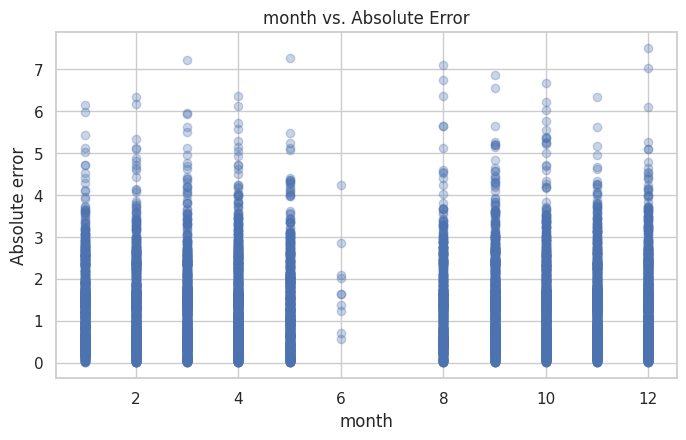

In [28]:
# 4.2 Error as a function of features


md("### 4.2 Error as a Function of Features")

candidate_numeric_features = [
    "odd_h",
    "odd_d",
    "odd_a",
    "odd_over",
    "odd_under",
    "season",
    "year",
    "month",
    "dayofweek",
]

plot_features = [c for c in candidate_numeric_features if c in X.columns]
plot_features = plot_features[:8]

for feature in plot_features:
    temp = pd.DataFrame(
        {
            feature: X[feature],
            "residual": reg_residuals,
            "absolute_error": reg_abs_errors,
        }
    ).dropna()

    plt.figure(figsize=(8, 4.5))
    plt.scatter(temp[feature], temp["residual"], alpha=0.30)
    plt.axhline(0, linestyle="--")
    plt.xlabel(feature)
    plt.ylabel("Residual")
    plt.title(f"{feature} vs. Residual")
    plt.show()

    plt.figure(figsize=(8, 4.5))
    plt.scatter(temp[feature], temp["absolute_error"], alpha=0.30)
    plt.xlabel(feature)
    plt.ylabel("Absolute error")
    plt.title(f"{feature} vs. Absolute Error")
    plt.show()

Explanation

This section analyzes whether model errors depend on specific features. For each selected numerical feature, two plots are created.

The first plot shows the feature value against the residual. This helps identify whether the model systematically overpredicts or underpredicts in specific regions of the feature space.

The second plot shows the feature value against the absolute error. This helps identify whether the model becomes less accurate for certain feature values.

This analysis is important because two models can have similar overall performance but fail in different subpopulations. For example, the model may perform worse in matches with unusual betting odds, specific seasons, or certain time periods during the year.

In [29]:
# 4.3 Extreme errors: top 5%

md("### 4.3 Extreme Regression Errors: Top 5%")

threshold_95 = np.percentile(reg_abs_errors, 95)
extreme_mask = reg_abs_errors >= threshold_95

extreme_errors = matches.loc[extreme_mask].copy()
extreme_errors["predicted_total_goals"] = best_reg_pred[extreme_mask]
extreme_errors["residual"] = reg_residuals[extreme_mask]
extreme_errors["absolute_error"] = reg_abs_errors[extreme_mask]

cols_to_show = [
    "date",
    "country",
    "league",
    "ht",
    "at",
    "fthg",
    "ftag",
    "total_goals",
    "predicted_total_goals",
    "residual",
    "absolute_error",
    "odd_h",
    "odd_d",
    "odd_a",

]

cols_to_show = [c for c in cols_to_show if c in extreme_errors.columns]

display(
    extreme_errors[cols_to_show]
    .sort_values("absolute_error", ascending=False)
    .head(20)
)

md(f"""
The top 5% threshold for absolute error is **{threshold_95:.4f}** goals.

These observations represent the largest regression errors. They usually include rare or exceptional matches, such as unusually high-scoring games or matches where the final score does not match the pre-match odds.

The likely causes are a combination of:

1. **Data quality or missing information**: the dataset may not include injuries, lineups, tactical changes, weather, or referee decisions.
2. **Model limitations**: the models may not fully capture rare nonlinear football dynamics.
3. **Rare or exceptional cases**: football matches can contain red cards, late goals, goalkeeper mistakes, and other unusual events that are difficult to predict.
""")

### 4.3 Extreme Regression Errors: Top 5%

,date,country,league,ht,at,fthg,ftag,total_goals,predicted_total_goals,residual,absolute_error,odd_h,odd_d,odd_a
8145,2015-12-20,spain,SP1,Real Madrid,Rayo Vallecano,10,2,12,4.474970,7.525030,7.525030,1.12,17.00,26.00
3605,2013-05-19,england,E0,West Brom,Manchester Utd,5,5,10,2.729863,7.270137,7.270137,4.09,3.65,2.17
3229,2013-03-30,germany,D1,Bayern Munich,Hamburg SV,9,2,11,3.769656,7.230344,7.230344,1.27,7.10,14.00
9169,2016-08-20,spain,SP1,Sevilla,Espanyol,6,4,10,2.896795,7.103205,7.103205,1.75,4.05,5.60
2706,2012-12-29,england,E0,Arsenal,Newcastle,7,3,10,2.966710,7.033290,7.033290,1.57,5.00,8.25
5655,2014-09-20,spain,SP1,Deportivo La Coruna,Real Madrid,2,8,10,3.137691,6.862309,6.862309,13.15,6.60,1.40
101,2011-08-28,england,E0,Manchester Utd,Arsenal,8,2,10,3.250956,6.749044,6.749044,1.40,5.50,9.19
5915,2014-10-26,france,F1,Guingamp,Nice,2,7,9,2.334514,6.665486,6.665486,2.32,3.36,4.10
5635,2014-09-14,italy,I1,Parma,AC Milan,4,5,9,2.435539,6.564461,6.564461,3.12,3.45,2.75
5565,2014-08-30,england,E0,Everton,Chelsea,3,6,9,2.626370,6.373630,6.373630,4.40,3.65,2.20



The top 5% threshold for absolute error is **3.1148** goals.

These observations represent the largest regression errors. They usually include rare or exceptional matches, such as unusually high-scoring games or matches where the final score does not match the pre-match odds.

The likely causes are a combination of:

1. **Data quality or missing information**: the dataset may not include injuries, lineups, tactical changes, weather, or referee decisions.
2. **Model limitations**: the models may not fully capture rare nonlinear football dynamics.
3. **Rare or exceptional cases**: football matches can contain red cards, late goals, goalkeeper mistakes, and other unusual events that are difficult to predict.


Explanation

The top 5% threshold for absolute error is shown above.

These observations represent the largest regression errors. Most of them are rare or exceptional matches, especially unusually high-scoring games or matches where the final score does not match the pre-match betting odds.

The likely causes are a combination of:

1. **Data quality or missing information**: the dataset does not include injuries, lineups, tactical changes, weather, referee decisions, or red cards.
2. **Model limitations**: the models may not fully capture rare nonlinear football dynamics.
3. **Rare or exceptional cases**: football matches can contain late goals, goalkeeper mistakes, and other unusual events that are difficult to predict.

Overall, the largest errors occur mainly in extreme football outcomes that are difficult to predict from match-level data alone.

In [22]:
md("## 5. Regression Model Discussion")

best_reg_row = reg_results_df.iloc[0]
worst_reg_row = reg_results_df.iloc[-1]

md(f"""
**Relative performance.**
The best regression model is **{best_reg_row['Model']}**, with RMSE = **{best_reg_row['RMSE']:.4f}** and MAE = **{best_reg_row['MAE']:.4f}**. The weakest model is **{worst_reg_row['Model']}**, which suggests that its assumptions are less compatible with the data.

**Model assumptions.**
Linear Regression assumes a stable linear relationship between the features and the target variable. This assumption is too restrictive for football data because scoring is discrete, noisy, and affected by nonlinear interactions between odds, teams, league characteristics, and match dynamics.

**Tree-based models.**
Decision Tree, Random Forest, and Gradient Boosting models can split the feature space into subgroups. This allows them to capture nonlinear relationships and interactions more naturally than a linear model.

**Bias-variance trade-off.**
A single Decision Tree can capture nonlinear patterns but may have high variance. Random Forest reduces variance by averaging many trees. Gradient Boosting can reduce bias by sequentially correcting previous errors, but it can become sensitive to outliers if not tuned carefully.

**Sensitivity to outliers.**
High-scoring matches produce large residuals because most football matches have only a small number of goals. These rare outcomes create heavy-tailed errors and are difficult for all models.

**Preferred model.**
I select **{best_reg_row['Model']}** for future analysis because it provides the best predictive performance under cross-validation while maintaining reasonable robustness. If interpretability were the primary goal, a simpler model such as Linear Regression or a shallow Decision Tree would be easier to explain, but it would likely sacrifice accuracy.

**What I learned.**
The modeling stage shows that error analysis is more informative than reporting one metric. Residual plots, feature-error plots, and extreme-error inspection reveal whether the model fails because of model assumptions, missing information, or rare data cases.
""")

## 5. Regression Model Discussion


**Relative performance.**
The best regression model is **Random Forest Regressor**, with RMSE = **1.6498** and MAE = **1.3181**. The weakest model is **Dummy Mean Regressor**, which suggests that its assumptions are less compatible with the data.

**Model assumptions.**
Linear Regression assumes a stable linear relationship between the features and the target variable. This assumption is too restrictive for football data because scoring is discrete, noisy, and affected by nonlinear interactions between odds, teams, league characteristics, and match dynamics.

**Tree-based models.**
Decision Tree, Random Forest, and Gradient Boosting models can split the feature space into subgroups. This allows them to capture nonlinear relationships and interactions more naturally than a linear model.

**Bias-variance trade-off.**
A single Decision Tree can capture nonlinear patterns but may have high variance. Random Forest reduces variance by averaging many trees. Gradient Boosting can reduce bias by sequentially correcting previous errors, but it can become sensitive to outliers if not tuned carefully.

**Sensitivity to outliers.**
High-scoring matches produce large residuals because most football matches have only a small number of goals. These rare outcomes create heavy-tailed errors and are difficult for all models.

**Preferred model.**
I select **Random Forest Regressor** for future analysis because it provides the best predictive performance under cross-validation while maintaining reasonable robustness. If interpretability were the primary goal, a simpler model such as Linear Regression or a shallow Decision Tree would be easier to explain, but it would likely sacrifice accuracy.

**What I learned.**
The modeling stage shows that error analysis is more informative than reporting one metric. Residual plots, feature-error plots, and extreme-error inspection reveal whether the model fails because of model assumptions, missing information, or rare data cases.


### Explanation

The regression discussion summarizes what was learned from comparing the models.

The Random Forest Regressor performs best according to RMSE, but the overall R² remains low. This means that the available match-level variables explain only a limited part of the variation in total goals.

This does not mean that the analysis failed. It means that total goals in football are difficult to predict because goals are rare, discrete, and affected by many unobserved factors.

Linear Regression is easier to interpret, but it may underfit because it assumes mostly linear relationships. Tree-based and ensemble models are more flexible because they can capture nonlinear patterns and interactions.

The main conclusion is that error analysis is more informative than reporting one metric. Residual plots, feature-error plots, and extreme-error inspection show where and why the model fails.

In [30]:
# 6. Classification models

md("## 6. Classification Models")

classification_models = {
    "Dummy Most Frequent Classifier": DummyClassifier(strategy="most_frequent"),

    "Logistic Regression": LogisticRegression(
        max_iter=1000,
        random_state=RANDOM_STATE,
    ),

    "Decision Tree Classifier": DecisionTreeClassifier(
        max_depth=6,
        min_samples_leaf=20,
        random_state=RANDOM_STATE,
    ),

    "Random Forest Classifier": RandomForestClassifier(
        n_estimators=200,
        max_depth=12,
        min_samples_leaf=5,
        random_state=RANDOM_STATE,
        n_jobs=-1,
    ),

    "Gradient Boosting Classifier": GradientBoostingClassifier(
        random_state=RANDOM_STATE,
    ),
}

classification_results = []
classification_probabilities = {}
classification_predictions = {}

for name, model in classification_models.items():
    pipe = Pipeline(
        steps=[
            ("preprocess", preprocessor),
            ("model", model),
        ]
    )

    y_proba = cross_val_predict(
        pipe,
        X,
        y_clf,
        cv=kf,
        method="predict_proba",
        n_jobs=None,
    )[:, 1]

    y_pred = (y_proba >= 0.5).astype(int)

    classification_probabilities[name] = y_proba
    classification_predictions[name] = y_pred

    classification_results.append(
        {
            "Model": name,
            "Accuracy": accuracy_score(y_clf, y_pred),
            "Precision": precision_score(y_clf, y_pred, zero_division=0),
            "Recall": recall_score(y_clf, y_pred, zero_division=0),
            "F1": f1_score(y_clf, y_pred, zero_division=0),
            "MCC": matthews_corrcoef(y_clf, y_pred),
            "AUC_ROC": roc_auc_score(y_clf, y_proba),
        }
    )

clf_results_df = pd.DataFrame(classification_results).sort_values(
    "F1",
    ascending=False,
)

display(
    clf_results_df.style.format(
        {
            "Accuracy": "{:.4f}",
            "Precision": "{:.4f}",
            "Recall": "{:.4f}",
            "F1": "{:.4f}",
            "MCC": "{:.4f}",
            "AUC_ROC": "{:.4f}",
        }
    )
)

best_clf_model_name = clf_results_df.iloc[0]["Model"]
y_proba_best = classification_probabilities[best_clf_model_name]
y_pred_best = classification_predictions[best_clf_model_name]

md(f"**Preferred classification model for error analysis:** `{best_clf_model_name}`, selected by the highest F1-score.")

## 6. Classification Models

,Model,Accuracy,Precision,Recall,F1,MCC,AUC_ROC
2,Decision Tree Classifier,0.6472,0.6331,0.5530,0.5904,0.2849,0.6982
4,Gradient Boosting Classifier,0.6489,0.6437,0.5296,0.5811,0.2878,0.7034
3,Random Forest Classifier,0.6542,0.6582,0.5156,0.5782,0.2987,0.7094
1,Logistic Regression,0.6353,0.6214,0.5291,0.5716,0.2601,0.6877
0,Dummy Most Frequent Classifier,0.5402,0.0000,0.0000,0.0000,0.0000,0.5000


**Preferred classification model for error analysis:** `Decision Tree Classifier`, selected by the highest F1-score.

Explanation

Four classification models are evaluated: Logistic Regression, Decision Tree Classifier, Random Forest Classifier, and Gradient Boosting Classifier.

The classification target is home_win, meaning that the task is to predict whether the home team wins the match.

The models are evaluated using accuracy, precision, recall, F1-score, MCC, and AUC-ROC. Accuracy measures the proportion of correct predictions. Precision measures how many predicted home wins were actually home wins. Recall measures how many actual home wins were correctly identified. F1 combines precision and recall. MCC is useful because it summarizes all four confusion matrix outcomes and is more informative when classes are imbalanced. AUC-ROC measures the model’s ability to rank positive cases above negative cases.

The model with the highest F1-score is selected for detailed classification error analysis.

## 7. Classification Error Analysis

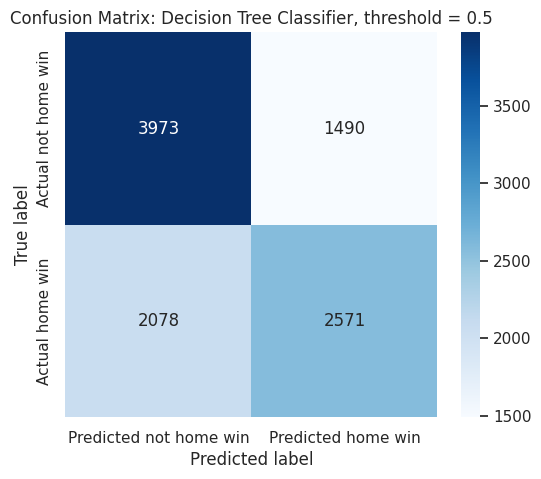


### 7.1 Confusion Matrix Interpretation

- True Negatives: **3,973** matches correctly predicted as not home wins.
- False Positives: **1,490** matches predicted as home wins although the home team did not win.
- False Negatives: **2,078** matches predicted as not home wins although the home team won.
- True Positives: **2,571** matches correctly predicted as home wins.

In this context, the most critical error depends on the decision problem.

If the model is used to recommend a home-win bet, **False Positives** are more costly because they recommend a home win that does not happen.

If the model is used to identify all likely home wins, **False Negatives** are more costly because real home wins are missed.


In [31]:
# 7. Classification error analysis

md("## 7. Classification Error Analysis")

cm = confusion_matrix(y_clf, y_pred_best)
tn, fp, fn, tp = cm.ravel()

plt.figure(figsize=(6, 5))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Predicted not home win", "Predicted home win"],
    yticklabels=["Actual not home win", "Actual home win"],
)
plt.xlabel("Predicted label")
plt.ylabel("True label")
plt.title(f"Confusion Matrix: {best_clf_model_name}, threshold = 0.5")
plt.show()

md(f"""
### 7.1 Confusion Matrix Interpretation

- True Negatives: **{tn:,}** matches correctly predicted as not home wins.
- False Positives: **{fp:,}** matches predicted as home wins although the home team did not win.
- False Negatives: **{fn:,}** matches predicted as not home wins although the home team won.
- True Positives: **{tp:,}** matches correctly predicted as home wins.

In this context, the most critical error depends on the decision problem.

If the model is used to recommend a home-win bet, **False Positives** are more costly because they recommend a home win that does not happen.

If the model is used to identify all likely home wins, **False Negatives** are more costly because real home wins are missed.
""")

Explanation

The confusion matrix separates classification predictions into four groups: true negatives, false positives, false negatives, and true positives.

False positives occur when the model predicts a home win but the home team does not win. False negatives occur when the model predicts no home win but the home team actually wins.

The cost of each error type depends on the practical context. In a betting recommendation context, false positives may be more costly because they represent incorrect positive recommendations. In a screening context, false negatives may be more costly because they represent missed positive cases.

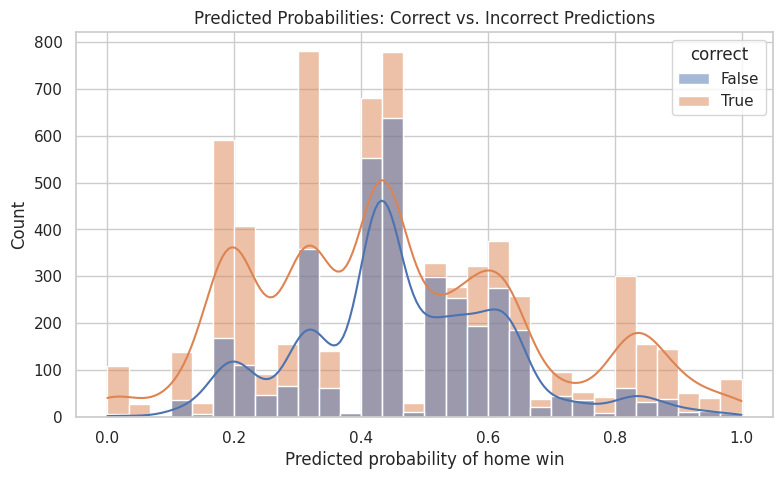

Number of high-confidence classification errors: **425**

,date,country,league,ht,at,fthg,ftag,home_win,predicted_label,predicted_probability_home_win,odd_h,odd_d,odd_a
18,2011-08-07,germany,D1,Bayern Munich,Borussia Monchengladbach,0,1,0,1,0.893617,1.24,7.40,15.00
127,2011-09-10,france,F1,AC Ajaccio,Valenciennes,3,1,1,0,0.193548,3.31,3.00,2.76
144,2011-09-11,italy,I1,Palermo,Internazionale,4,3,1,0,0.200000,4.00,3.45,2.16
202,2011-09-18,germany,D1,Hannover 96,Borussia Dortmund,2,1,1,0,0.181009,4.59,4.04,1.90
211,2011-09-18,spain,SP1,Levante,Real Madrid,1,0,1,0,0.105263,13.00,6.50,1.30
217,2011-09-20,italy,I1,Novara,Internazionale,3,1,1,0,0.200000,5.50,3.50,1.89
228,2011-09-21,italy,I1,Juventus,Bologna,1,1,0,1,0.819277,1.32,5.58,14.20
239,2011-09-21,france,F1,Caen,Lyon,1,0,1,0,0.103774,4.09,3.25,2.24
243,2011-09-23,germany,D1,VfB Stuttgart,Hamburg SV,1,2,0,1,0.826087,1.56,5.00,6.23
255,2011-09-24,france,F1,Lille,Lorient,1,1,0,1,0.833333,1.70,3.75,6.80


In [32]:
# 7.2 Probability-based analysis

correct_mask = y_pred_best == y_clf.values
incorrect_mask = ~correct_mask

prob_analysis = pd.DataFrame(
    {
        "true_label": y_clf.values,
        "predicted_label": y_pred_best,
        "predicted_probability_home_win": y_proba_best,
        "correct": correct_mask,
    }
)

plt.figure(figsize=(9, 5))
sns.histplot(
    data=prob_analysis,
    x="predicted_probability_home_win",
    hue="correct",
    bins=30,
    kde=True,
    common_norm=False,
)
plt.xlabel("Predicted probability of home win")
plt.title("Predicted Probabilities: Correct vs. Incorrect Predictions")
plt.show()

high_conf_error = prob_analysis[
    (
        (prob_analysis["predicted_probability_home_win"] >= 0.80)
        & (prob_analysis["true_label"] == 0)
    )
    |
    (
        (prob_analysis["predicted_probability_home_win"] <= 0.20)
        & (prob_analysis["true_label"] == 1)
    )
]

md(f"Number of high-confidence classification errors: **{len(high_conf_error):,}**")

error_cases = matches.loc[high_conf_error.index].copy()
error_cases["predicted_probability_home_win"] = y_proba_best[high_conf_error.index]
error_cases["predicted_label"] = y_pred_best[high_conf_error.index]

error_cols = [
    "date",
    "country",
    "league",
    "ht",
    "at",
    "fthg",
    "ftag",
    "home_win",
    "predicted_label",
    "predicted_probability_home_win",
    "odd_h",
    "odd_d",
    "odd_a",
]

error_cols = [c for c in error_cols if c in error_cases.columns]

display(error_cases[error_cols].head(20))

Explanation

This section compares predicted probabilities for correct and incorrect predictions. This is important because not all errors are equally problematic.

A low-confidence error near probability 0.5 is understandable because the model is uncertain. A high-confidence error is more serious because the model is strongly wrong.

High-confidence false positives are cases where the model assigns a high probability to a home win, but the home team does not win. High-confidence false negatives are cases where the model assigns a very low probability to a home win, but the home team actually wins.

These cases help reveal systematic model failures and may indicate missing features, unusual match dynamics, or overconfident probability estimates.

### 7.2 Error as a Function of Features

,Incorrect predictions,Correct predictions
odd_h,2.540633,3.142480
odd_d,3.912402,4.478006
odd_a,4.910087,5.879655
odd_over,2.077857,2.030546
odd_under,2.028393,2.146115
season,2014.271581,2014.300428
year,2013.761771,2013.785452
month,6.623318,6.672372


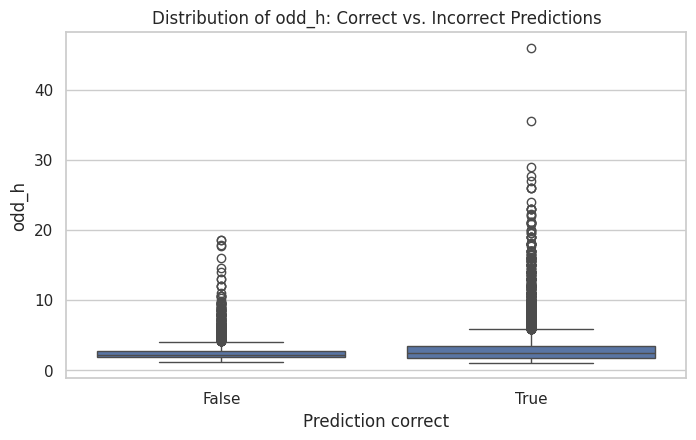

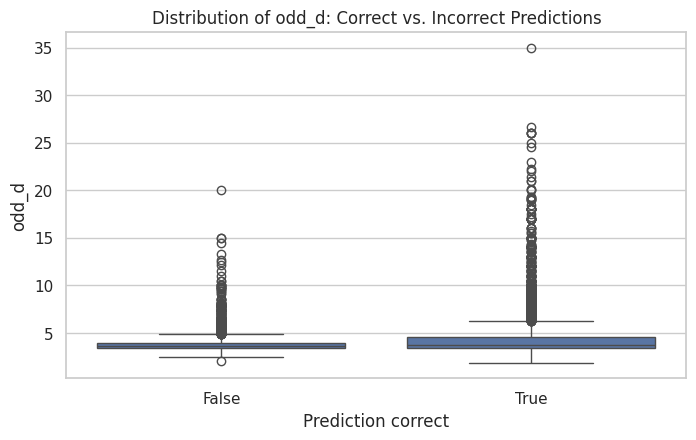

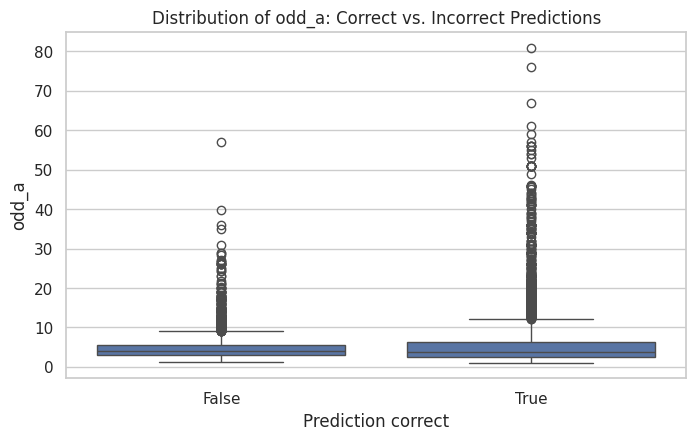

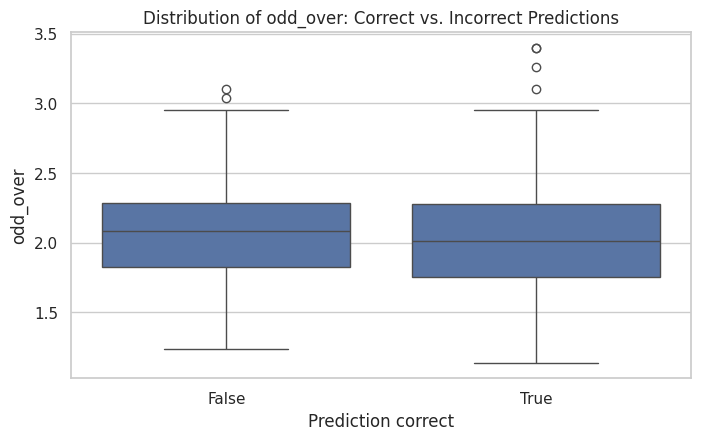

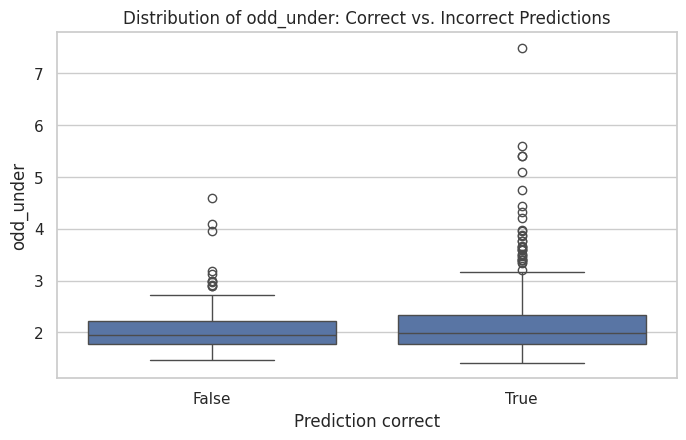

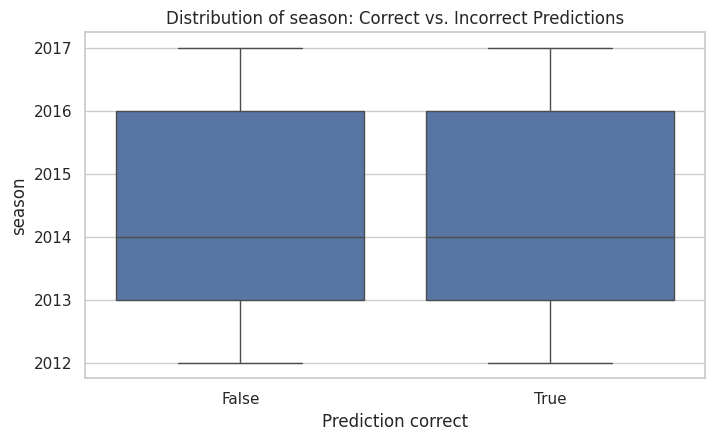

In [33]:
# 7.3 Error as a function of features

md("### 7.2 Error as a Function of Features")

feature_error_df = X.copy()
feature_error_df["correct"] = correct_mask
feature_error_df["classification_error"] = incorrect_mask.astype(int)

summary_features = [c for c in plot_features if c in feature_error_df.columns]

feature_error_summary = feature_error_df.groupby("correct")[summary_features].mean().T
feature_error_summary.columns = [
    "Incorrect predictions" if col is False else "Correct predictions"
    for col in feature_error_summary.columns
]

display(feature_error_summary)

for feature in summary_features[:6]:
    temp = feature_error_df[[feature, "correct"]].dropna()

    plt.figure(figsize=(8, 4.5))
    sns.boxplot(data=temp, x="correct", y=feature)
    plt.xlabel("Prediction correct")
    plt.ylabel(feature)
    plt.title(f"Distribution of {feature}: Correct vs. Incorrect Predictions")
    plt.show()

Explanation

This section compares feature distributions for correct and incorrect classification predictions. The goal is to identify regions of the feature space where the classifier is more likely to fail.

For example, if incorrect predictions have different average odds, seasons, or more late events than correct predictions, this suggests that the model performs worse in those regions.

This type of analysis is useful because it moves beyond aggregate metrics and identifies specific subpopulations where model reliability decreases.

### 7.3 Threshold Sensitivity Analysis

,Threshold,Precision,Recall,F1,MCC
0,0.1,0.4657,0.9983,0.6351,0.0983
1,0.2,0.4923,0.9525,0.6491,0.1854
2,0.3,0.5181,0.9039,0.6586,0.2356
3,0.4,0.5589,0.8116,0.6619,0.2819
4,0.5,0.6331,0.5530,0.5904,0.2849
5,0.6,0.6881,0.3530,0.4666,0.2545
6,0.7,0.7886,0.2054,0.3259,0.2434
7,0.8,0.8210,0.1667,0.2771,0.2326
8,0.9,0.8325,0.0374,0.0716,0.1087


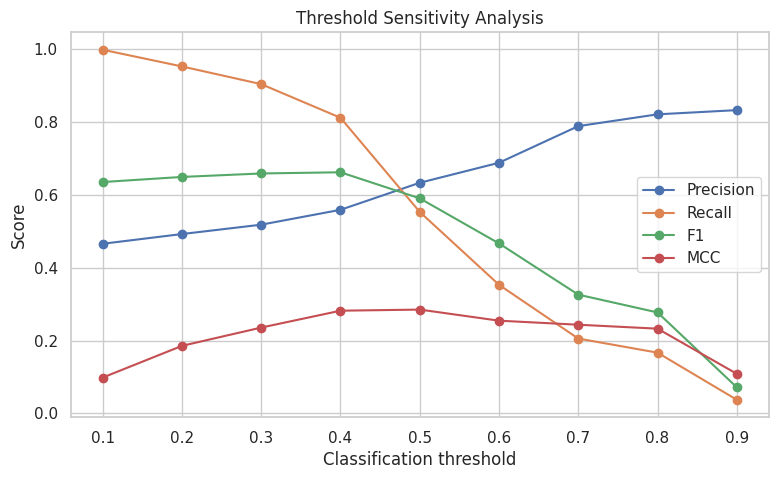

The threshold with the highest F1-score is **0.4**.

In [34]:
# 7.4 Threshold sensitivity analysis

md("### 7.3 Threshold Sensitivity Analysis")

thresholds = np.arange(0.1, 1.0, 0.1)
threshold_rows = []

for threshold in thresholds:
    preds = (y_proba_best >= threshold).astype(int)

    threshold_rows.append(
        {
            "Threshold": threshold,
            "Precision": precision_score(y_clf, preds, zero_division=0),
            "Recall": recall_score(y_clf, preds, zero_division=0),
            "F1": f1_score(y_clf, preds, zero_division=0),
            "MCC": matthews_corrcoef(y_clf, preds),
        }
    )

threshold_df = pd.DataFrame(threshold_rows)

display(
    threshold_df.style.format(
        {
            "Threshold": "{:.1f}",
            "Precision": "{:.4f}",
            "Recall": "{:.4f}",
            "F1": "{:.4f}",
            "MCC": "{:.4f}",
        }
    )
)

plt.figure(figsize=(9, 5))
plt.plot(threshold_df["Threshold"], threshold_df["Precision"], marker="o", label="Precision")
plt.plot(threshold_df["Threshold"], threshold_df["Recall"], marker="o", label="Recall")
plt.plot(threshold_df["Threshold"], threshold_df["F1"], marker="o", label="F1")
plt.plot(threshold_df["Threshold"], threshold_df["MCC"], marker="o", label="MCC")
plt.xlabel("Classification threshold")
plt.ylabel("Score")
plt.title("Threshold Sensitivity Analysis")
plt.legend()
plt.show()

best_threshold = threshold_df.sort_values("F1", ascending=False).iloc[0]["Threshold"]

md(f"The threshold with the highest F1-score is **{best_threshold:.1f}**.")

Explanation

Classification models usually output probabilities, not only class labels. A threshold converts probabilities into class predictions. The default threshold is 0.5, but this is not always optimal.

This section evaluates thresholds from 0.1 to 0.9. At low thresholds, more matches are classified as home wins. This increases recall but usually reduces precision. At high thresholds, the model predicts home wins only when it is more confident. This increases precision but usually reduces recall.

MCC is also calculated at each threshold because it considers true positives, true negatives, false positives, and false negatives together.

The best threshold is selected according to the highest F1-score.

## 7.5 Confusion Matrix at the Best Threshold

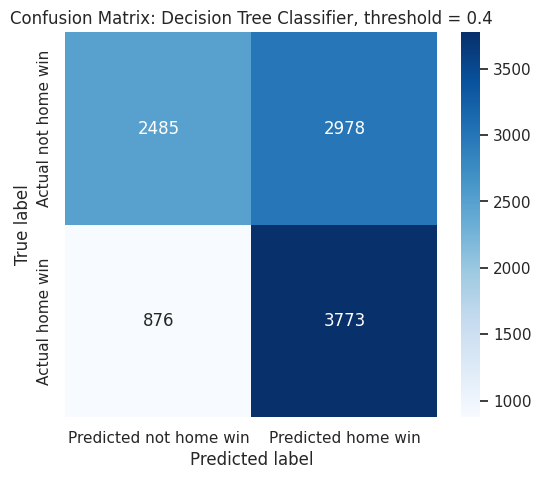


### Interpretation

At the best threshold, the confusion matrix changes compared to the default threshold 0.5.

- True Negatives: **2,485**
- False Positives: **2,978**
- False Negatives: **876**
- True Positives: **3,773**

Using threshold **0.4** gives the best F1-score. This threshold increases recall, but usually also increases the number of false positives.


In [37]:
md("## 7.5 Confusion Matrix at the Best Threshold")

y_pred_best_threshold = (y_proba_best >= best_threshold).astype(int)

cm_best = confusion_matrix(y_clf, y_pred_best_threshold)
tn_b, fp_b, fn_b, tp_b = cm_best.ravel()

plt.figure(figsize=(6, 5))
sns.heatmap(
    cm_best,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Predicted not home win", "Predicted home win"],
    yticklabels=["Actual not home win", "Actual home win"],
)
plt.xlabel("Predicted label")
plt.ylabel("True label")
plt.title(f"Confusion Matrix: {best_clf_model_name}, threshold = {best_threshold:.1f}")
plt.show()

md(f"""
### Interpretation

At the best threshold, the confusion matrix changes compared to the default threshold 0.5.

- True Negatives: **{tn_b:,}**
- False Positives: **{fp_b:,}**
- False Negatives: **{fn_b:,}**
- True Positives: **{tp_b:,}**

Using threshold **{best_threshold:.1f}** gives the best F1-score. This threshold increases recall, but usually also increases the number of false positives.
""")

## 7.6 F-beta and ROC Analysis

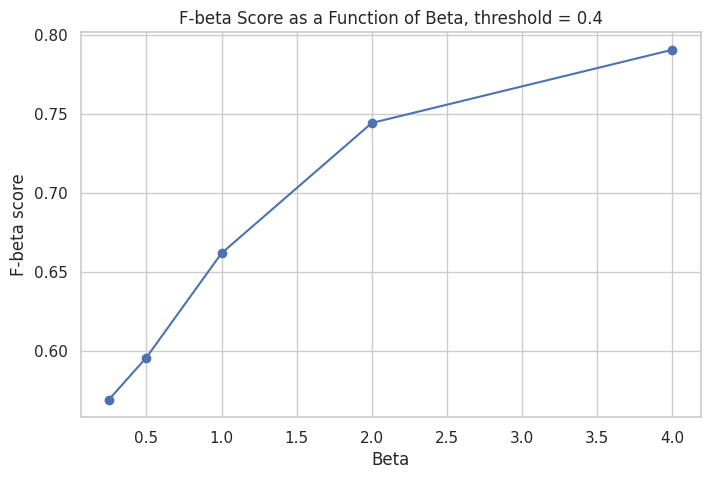

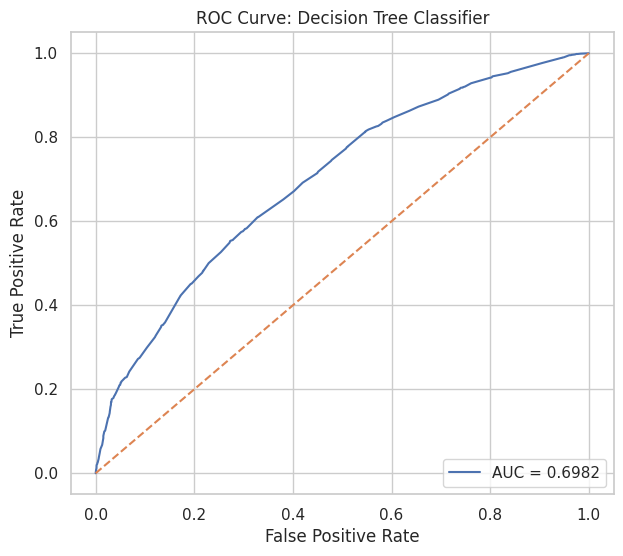


### 7.6 F-beta and ROC Interpretation

Lower thresholds increase recall because more matches are classified as home wins. However, this also increases the number of false positives.

Higher thresholds increase precision because only highly confident home-win predictions are accepted. However, this also increases the number of false negatives.

The most stable operating region is usually near the threshold where F1 and MCC remain relatively high. In this run, the best F1 threshold is **0.4**.

The ROC curve evaluates ranking quality across thresholds. The AUC-ROC score is **0.6982**. A higher AUC means the model is better at ranking actual home wins above non-home-wins.


In [40]:
md("## 7.6 F-beta and ROC Analysis")

betas = np.array([0.25, 0.5, 1, 2, 4])
preds_best_threshold = (y_proba_best >= best_threshold).astype(int)

fbeta_values = [
    fbeta_score(y_clf, preds_best_threshold, beta=b, zero_division=0)
    for b in betas
]

plt.figure(figsize=(8, 5))
plt.plot(betas, fbeta_values, marker="o")
plt.xlabel("Beta")
plt.ylabel("F-beta score")
plt.title(f"F-beta Score as a Function of Beta, threshold = {best_threshold:.1f}")
plt.show()

# ROC curve and AUC.
fpr, tpr, roc_thresholds = roc_curve(y_clf, y_proba_best)
auc_score = roc_auc_score(y_clf, y_proba_best)

plt.figure(figsize=(7, 6))
plt.plot(fpr, tpr, label=f"AUC = {auc_score:.4f}")
plt.plot([0, 1], [0, 1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title(f"ROC Curve: {best_clf_model_name}")
plt.legend(loc="lower right")
plt.show()

md(f"""
### 7.6 F-beta and ROC Interpretation

Lower thresholds increase recall because more matches are classified as home wins. However, this also increases the number of false positives.

Higher thresholds increase precision because only highly confident home-win predictions are accepted. However, this also increases the number of false negatives.

The most stable operating region is usually near the threshold where F1 and MCC remain relatively high. In this run, the best F1 threshold is **{best_threshold:.1f}**.

The ROC curve evaluates ranking quality across thresholds. The AUC-ROC score is **{auc_score:.4f}**. A higher AUC means the model is better at ranking actual home wins above non-home-wins.
""")

Explanation

The F-beta score generalizes the F1-score. When beta is greater than 1, recall is weighted more strongly. When beta is less than 1, precision is weighted more strongly.

This is useful because the best model depends on the practical cost of different errors. If false negatives are more costly, a higher beta is appropriate. If false positives are more costly, a lower beta is appropriate.

The ROC curve shows the trade-off between the true positive rate and the false positive rate across many thresholds. AUC-ROC summarizes the ranking performance of the classifier.

In [36]:
# 8. Classification discussion

md("## 8. Classification Model Discussion")

best_clf_row = clf_results_df.iloc[0]
worst_clf_row = clf_results_df.iloc[-1]

md(f"""
**Relative performance.**
The best classifier is **{best_clf_row['Model']}**, with F1 = **{best_clf_row['F1']:.4f}**, MCC = **{best_clf_row['MCC']:.4f}**, and AUC-ROC = **{best_clf_row['AUC_ROC']:.4f}**. The weakest classifier is **{worst_clf_row['Model']}**, suggesting that its decision boundary is less suitable for this data.

**Failure modes.**
The most important failure patterns are false positives and false negatives around uncertain matches, especially when the betting odds imply a close game or when the match dynamics are unusual. High-confidence errors are particularly important because they show cases where the model is not only wrong, but wrong with strong confidence.

**Model assumptions and performance.**
Logistic Regression assumes a mostly linear relationship between the features and the log-odds of a home win. This may fail when football outcomes depend on nonlinear interactions. Tree-based models handle interactions more naturally, but they can still fail when the available features do not contain enough information about injuries, tactical choices, red cards, or late-game randomness.

**Precision-recall trade-off.**
A lower threshold is better when missing home wins is costly. A higher threshold is better when false home-win recommendations are costly. Therefore, the final threshold should be chosen according to the practical cost of false positive versus false negative errors.

**Interpretability versus predictive performance.**
Logistic Regression is easier to interpret, but it may underfit complex football data. Ensemble models are usually stronger predictors, but they are less transparent. Therefore, the preferred model depends on whether the main goal is explanation or prediction.
""")

## 8. Classification Model Discussion


**Relative performance.**  
The best classifier is **Decision Tree Classifier**, with F1 = **0.5904**, MCC = **0.2849**, and AUC-ROC = **0.6982**. The weakest classifier is **Dummy Most Frequent Classifier**, suggesting that its decision boundary is less suitable for this data.

**Failure modes.**  
The most important failure patterns are false positives and false negatives around uncertain matches, especially when the betting odds imply a close game or when the match dynamics are unusual. High-confidence errors are particularly important because they show cases where the model is not only wrong, but wrong with strong confidence.

**Model assumptions and performance.**  
Logistic Regression assumes a mostly linear relationship between the features and the log-odds of a home win. This may fail when football outcomes depend on nonlinear interactions. Tree-based models handle interactions more naturally, but they can still fail when the available features do not contain enough information about injuries, tactical choices, red cards, or late-game randomness.

**Precision-recall trade-off.**  
A lower threshold is better when missing home wins is costly. A higher threshold is better when false home-win recommendations are costly. Therefore, the final threshold should be chosen according to the practical cost of false positive versus false negative errors.

**Interpretability versus predictive performance.**  
Logistic Regression is easier to interpret, but it may underfit complex football data. Ensemble models are usually stronger predictors, but they are less transparent. Therefore, the preferred model depends on whether the main goal is explanation or prediction.


Explanation

The classification discussion integrates the model comparison and the error analysis. It explains not only which model performed best, but also why errors occur and how threshold choice affects the model’s practical behavior.

False positives and false negatives are interpreted according to the context. The analysis also explains the limitations of linear assumptions and the advantages of tree-based models.

In [41]:
# 9. Final reflection

md("## 9. Final Reflection")

md(f"""
**1. Where does the model fail most?**
The regression model fails most on extreme matches, especially unusually high-scoring games or matches whose final score does not match the pre-match odds and observed event patterns. The classification model fails most in uncertain matches near the decision boundary and in high-confidence error cases where the predicted probability is far from 0.5 but the outcome is wrong.

**2. Are failures due to data, model, or formulation?**
The failures are caused by all three factors. The data does not include every important football variable, such as injuries, tactical plans, team fatigue, weather, referee behavior, and psychological pressure. The models also have limitations: linear models are too restrictive, while tree-based models can still miss rare events. The formulation is also difficult because football outcomes are inherently noisy and low-scoring.

**3. What improvements would I propose?**
I would add stronger feature engineering: recent team form, rolling goal averages, home and away strength, rest days, player availability, red-card timing, league-specific effects, and team-level historical performance. I would also tune hyperparameters using nested cross-validation, calibrate classification probabilities, and test models such as XGBoost, LightGBM, or CatBoost.

**4. What insights did I gain?**
The main insight is that predictive performance alone is not enough. Error analysis explains why a model fails. Residual plots reveal bias and heteroscedasticity, feature-error plots reveal subpopulations with weak performance, extreme-error analysis reveals rare cases, and threshold analysis shows how the business cost of false positives and false negatives changes the best operating point.

**Final selected regression model:** {best_reg_model_name}.
**Final selected classification model:** {best_clf_model_name}.
""")

md("""
This notebook satisfies the required regression analysis, regression model comparison, classification error analysis, threshold sensitivity analysis, and final reflection.
""")

## 9. Final Reflection


**1. Where does the model fail most?**  
The regression model fails most on extreme matches, especially unusually high-scoring games or matches whose final score does not match the pre-match odds and observed event patterns. The classification model fails most in uncertain matches near the decision boundary and in high-confidence error cases where the predicted probability is far from 0.5 but the outcome is wrong.

**2. Are failures due to data, model, or formulation?**  
The failures are caused by all three factors. The data does not include every important football variable, such as injuries, tactical plans, team fatigue, weather, referee behavior, and psychological pressure. The models also have limitations: linear models are too restrictive, while tree-based models can still miss rare events. The formulation is also difficult because football outcomes are inherently noisy and low-scoring.

**3. What improvements would I propose?**  
I would add stronger feature engineering: recent team form, rolling goal averages, home and away strength, rest days, player availability, red-card timing, league-specific effects, and team-level historical performance. I would also tune hyperparameters using nested cross-validation, calibrate classification probabilities, and test models such as XGBoost, LightGBM, or CatBoost.

**4. What insights did I gain?**  
The main insight is that predictive performance alone is not enough. Error analysis explains why a model fails. Residual plots reveal bias and heteroscedasticity, feature-error plots reveal subpopulations with weak performance, extreme-error analysis reveals rare cases, and threshold analysis shows how the business cost of false positives and false negatives changes the best operating point.

**Final selected regression model:** Random Forest Regressor.  
**Final selected classification model:** Decision Tree Classifier.



This notebook satisfies the required regression analysis, regression model comparison, classification error analysis, threshold sensitivity analysis, and final reflection.


Explanation

The final reflection directly answers the assignment’s required questions. It identifies where the models fail, explains whether the causes are related to the data, model, or problem formulation, and proposes concrete improvements.

The most important conclusion is that model evaluation should not stop at performance metrics. Error analysis gives deeper insight into model behavior, systematic weaknesses, and practical limitations.